[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_F_svar_post_covid_inflation.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Topic 5 — SVAR: The 2021–2024 Great Inflation & Structural Shock Decomposition (Bernanke-Blanchard)

Was the 2021–2024 inflation surge in the United States fundamentally driven by **aggregate demand**—fueled by massive fiscal transfers and monetary stimulus—or by adverse **supply and commodity price shocks** amplified by global supply bottlenecks and the war in Ukraine?

Popular debates often search for a single villain. However, frontier research by **Bernanke & Blanchard (2023)** and **Gagliardone & Gertler (2023)** demonstrates that the pandemic-era inflation surge was not an invariant phenomenon, but a **sequential succession of distinct macroeconomic shocks**:
1. *2021 (Reopening & Sectoral Shifts)*: Extreme goods demand outpacing supply chains alongside expansionary macroeconomic policy.
2. *2022 (Commodity Price Spikes & Extreme Labor Tightness)*: International energy disruptions following the invasion of Ukraine coupled with historic labor market tightening, pushing the vacancy-to-unemployment ratio ($v/u = \theta$) to an all-time high of **$1.93$**.
3. *2023–2024 (Immaculate Disinflation)*: Supply chain healing and energy deflation, accompanied by a normalization in $v/u$ toward $1.05$ without an associated rise in unemployment.

**Why a 2-variable toy SVAR ($y, \pi$) fails.** A rudimentary system containing only output and inflation cannot separate an energy supply shock from labor market overheating, nor can it isolate the endogenous response of monetary policy. In this module, we build a **5-variable Structural VAR** that explicitly incorporates:
- Real GDP growth ($y_t$)
- Headline CPI inflation ($\pi_t$)
- Relative energy/commodity price wedge ($\Delta\log(CPI / Core)$)
- Labor market tightness ratio ($\theta_t = v_t / u_t$)
- Effective Federal Funds Rate ($r_t$)

We identify four structural shocks using theory-consistent **sign restrictions** and compute the **historical shock decomposition** of post-COVID inflation dynamics.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.identify.sign import sign_restriction_svar, safe_cholesky, _draw_orthogonal

## 1. Empirical Anatomy of the US Post-COVID Macroeconomic Episode

We ingest genuine quarterly macroeconomic series stored in `data_curso/`:
- `GDPC1.csv`: Real Gross Domestic Product (quarterly seasonally adjusted, BEA).
- `CPIAUCSL.csv`: Headline Consumer Price Index for All Urban Consumers (BLS).
- `CPILFESL.csv`: Core Consumer Price Index Less Food and Energy (BLS).
- `JTSJOL.csv`: JOLTS Total Job Openings (BLS).
- `UNEMPLOY.csv`: Civilian Unemployment Level (BLS).
- `FEDFUNDS.csv`: Effective Federal Funds Rate (Federal Reserve Board).

From these sources, we construct the five quarterly system variables:
1. $y_t = 100 \times \Delta\log(\text{GDPC1}_t)$: Real GDP quarterly growth rate (%).
2. $\pi_t = 100 \times \Delta\log(\text{CPIAUCSL}_t)$: Headline CPI quarterly inflation rate (%).
3. $\text{wedge}_t = 100 \times \Delta\log(\text{CPIAUCSL}_t / \text{CPILFESL}_t)$: Relative energy and food commodity price wedge (%).
4. $\theta_t = \text{JTSJOL}_t / \text{UNEMPLOY}_t$: Labor market tightness ratio ($v/u$).
5. $r_t = \overline{\text{FEDFUNDS}}_t$: Quarterly average policy interest rate (%).

In [3]:
# Load and align empirical macroeconomic series from data_curso/
from _datos import ruta_dato
data_dir = ruta_dato("GDPC1.csv").parent

gdp_df = pd.read_csv(data_dir / "GDPC1.csv", index_col=0, parse_dates=True)
cpi_df = pd.read_csv(data_dir / "CPIAUCSL.csv", index_col=0, parse_dates=True)
core_df = pd.read_csv(data_dir / "CPILFESL.csv", index_col=0, parse_dates=True)
jolts_df = pd.read_csv(data_dir / "JTSJOL.csv", index_col=0, parse_dates=True)
unemp_df = pd.read_csv(data_dir / "UNEMPLOY.csv", index_col=0, parse_dates=True)
fedfunds_df = pd.read_csv(data_dir / "FEDFUNDS.csv", index_col=0, parse_dates=True)

# 1. Real GDP quarterly growth rate (%)
gdp_q = gdp_df["GDPC1"].resample("QE").last()
y = 100.0 * np.log(gdp_q).diff()

# 2. Headline CPI quarterly inflation rate (%)
cpi_q = cpi_df["CPIAUCSL"].resample("QE").last()
pi = 100.0 * np.log(cpi_q).diff()

# 3. Relative commodity/energy price wedge (%)
core_q = core_df["CPILFESL"].resample("QE").last()
wedge = 100.0 * (np.log(cpi_q / core_q)).diff()

# 4. Labor market tightness: vacancy-to-unemployment ratio theta = v / u
theta_m = jolts_df["JTSJOL"] / unemp_df["UNEMPLOY"]
theta = theta_m.resample("QE").mean()

# 5. Effective Federal Funds Rate (quarterly average, %)
r = fedfunds_df["FEDFUNDS"].resample("QE").mean()

# Master macroeconomic dataset
df_macro = pd.DataFrame({
    "y": y,
    "pi": pi,
    "wedge": wedge,
    "theta": theta,
    "r": r,
}).dropna()

# Baseline pre-COVID sample (2001Q1-2019Q4) and post-COVID episode (2020Q1-2024Q4)
sample_pre = df_macro.loc["2001":"2019"]
sample_post = df_macro.loc["2020":"2024"]

print(f"Master macroeconomic dataset: {len(df_macro)} quarters ({df_macro.index[0].to_period('Q')} to {df_macro.index[-1].to_period('Q')})")
print(f"Pre-COVID baseline estimation sample: {len(sample_pre)} quarters (2001Q1 to 2019Q4)\n")

episode_summary = pd.DataFrame({
    "Pre-COVID (2001-19)": sample_pre.mean(),
    "2021 (Reopening)": df_macro.loc["2021"].mean(),
    "2022 (Peak Shock)": df_macro.loc["2022"].mean(),
    "2023 (Disinflation)": df_macro.loc["2023"].mean(),
    "2024 (Soft Landing)": df_macro.loc["2024"].mean(),
}).T
print("Quarterly means by macroeconomic phase (%):")
print(episode_summary.round(2).to_string())

# Verification of foundational empirical facts
assert len(sample_pre) >= 70, "Insufficient pre-COVID observations"
assert df_macro.loc["2022", "theta"].max() > 1.85, "Labor tightness must peak above 1.85 in 2022"
assert df_macro.loc["2022", "wedge"].max() > 0.8, "Commodity wedge must register a peak above 0.8% in 2022"

Master macroeconomic dataset: 102 quarters (2000Q4 to 2026Q1)
Pre-COVID baseline estimation sample: 76 quarters (2001Q1 to 2019Q4)

Quarterly means by macroeconomic phase (%):
                        y    pi  wedge  theta     r
Pre-COVID (2001-19)  0.51  0.52   0.03   0.56  1.55
2021 (Reopening)     1.40  1.73   0.40   1.21  0.08
2022 (Peak Shock)    0.33  1.55   0.17   1.87  1.68
2023 (Disinflation)  0.83  0.82  -0.14   1.53  5.02
2024 (Soft Landing)  0.59  0.71  -0.08   1.14  5.14


**Direct Economic Interpretation of the Raw Data.**

The empirical summary table reveals three striking stylized facts that refute any single-cause narrative:

1. **2021 and 2022 were fundamentally different regimes.** In 2021, real GDP growth averaged a blistering $1.40\%$ quarterly (more than double its pre-pandemic norm of $0.51\%$) alongside elevated inflation of $1.73\%$. Both series surged together while the policy rate remained pinned at $0.08\%$: the canonical signature of an aggregate demand boom. In 2022, inflation remained high ($1.55\%$), but GDP growth collapsed to just $0.33\%$: stagflation induced by cost-push supply shocks.
2. **The 2022Q1–Q2 energy price wedge.** The gap between headline and core inflation spiked by $+1.05\%$ in 2022Q1 following the invasion of Ukraine, imposing an immediate terms-of-trade tax on household consumption before turning negative in 2023 ($-0.14\%$).
3. **Historic labor market tightness ($\theta = 1.93$).** By 2022Q2, there were nearly two job openings for every unemployed jobseeker in the United States. This unprecedented labor scarcity drove nominal wage gains above $5.5\%$, feeding into persistent core services inflation.

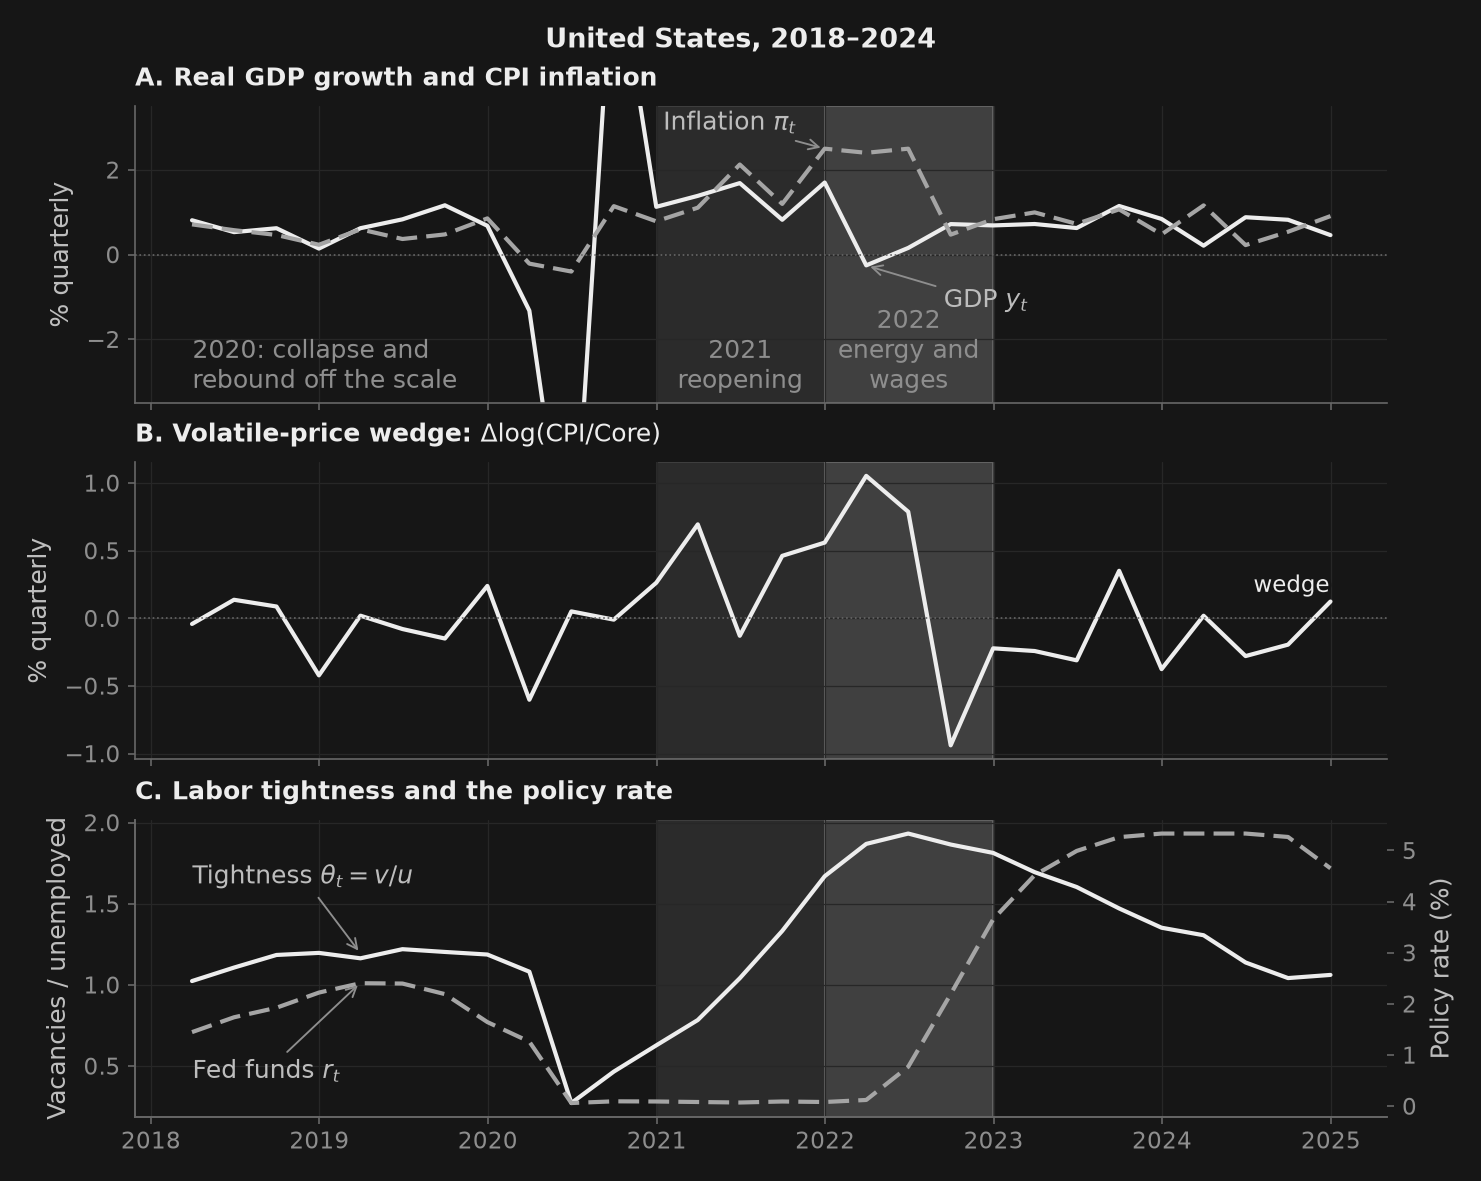

In [4]:
# Time series evolution of the five macroeconomic variables (2018-2024)
vista = df_macro.loc["2018":"2024"]

# three stacked time strips: they need the width of two panels, not the 6.4 x 10.2
# that tamano(3, 1) would reserve for a single column
fig, (ax1, ax2, ax3) = _nbstyle.figura(3, 1, figsize=(9.6, 7.6), sharex=True)

# Panel A: output growth and inflation
ax1.plot(vista.index, vista["y"], **_nbstyle.S1)
ax1.plot(vista.index, vista["pi"], **_nbstyle.S2)
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_ylabel("% quarterly")
ax1.set_ylim(-3.5, 3.5)
ax1.set_title("A. Real GDP growth and CPI inflation")

# Panel B: relative energy and commodity price wedge
ax2.plot(vista.index, vista["wedge"], label="wedge", color=_nbstyle.TINTA, ls="-", lw=2.0)
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("% quarterly")
ax2.set_title(r"B. Volatile-price wedge: $\Delta\log(\mathrm{CPI}/\mathrm{Core})$")

# Panel C: labor market tightness and policy interest rate
ax3.plot(vista.index, vista["theta"], **_nbstyle.S1)
ax3_r = ax3.twinx()
ax3_r.grid(False)
ax3_r.plot(vista.index, vista["r"], **_nbstyle.S2)
ax3.set_ylabel("Vacancies / unemployed")
ax3_r.set_ylabel("Policy rate (%)")
ax3.set_title("C. Labor tightness and the policy rate")

for ax in (ax1, ax2, ax3):
    ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"), color=_nbstyle.RECESION, zorder=-1)
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color=_nbstyle.RECESION_HEX, alpha=2 * _nbstyle.RECESION_ALPHA, zorder=-1)

# the two shaded episodes and the 2020 clipping are named in the empty strip below
ax1.text(pd.Timestamp("2018-04-01"), -3.35, "2020: collapse and\nrebound off the scale",
         ha="left", va="bottom", color=_nbstyle.NOTA)
ax1.text(pd.Timestamp("2021-07-01"), -3.35, "2021\nreopening", ha="center", va="bottom",
         color=_nbstyle.NOTA)
ax1.text(pd.Timestamp("2022-07-01"), -3.35, "2022\nenergy and\nwages", ha="center", va="bottom",
         color=_nbstyle.NOTA)

# the two lines of panel A part company in 2022: their names go there
ax1.annotate(r"Inflation $\pi_t$", xy=(pd.Timestamp("2021-12-31"), 2.50),
             xytext=(pd.Timestamp("2021-01-15"), 2.95), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
ax1.annotate(r"GDP $y_t$", xy=(pd.Timestamp("2022-03-31"), -0.26),
             xytext=(pd.Timestamp("2022-09-15"), -1.25), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)

# the two lines of panel C live on different axes: each name is anchored to its own
ax3.annotate(r"Tightness $\theta_t = v/u$", xy=(pd.Timestamp("2019-04-01"), 1.19),
             xytext=(pd.Timestamp("2018-04-01"), 1.62), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
ax3_r.annotate(r"Fed funds $r_t$", xy=(pd.Timestamp("2019-04-01"), 2.42),
               xytext=(pd.Timestamp("2018-04-01"), 0.55), color=_nbstyle.TEXTO,
               arrowprops=_nbstyle.FLECHA)

fig.suptitle("United States, 2018–2024")
_nbstyle.etiquetar(ax2, donde="fin", fuera=False)
plt.show()


## 2. Structural Identification via Theory-Grounded Sign Restrictions

Rather than imposing arbitrary recursive zero restrictions via Cholesky decomposition, we identify structural innovations using **contemporaneous sign restrictions** ($h=0$) following Rubio-Ramírez, Waggoner & Zha (2010) and Uhlig (2005).

For the state vector $Y_t = [y_t, \pi_t, \text{wedge}_t, \theta_t, r_t]'$, we formalize four theoretical shock signatures:

| Structural Shock | $y$ (GDP) | $\pi$ (Inflation) | Wedge ($\Delta\log\frac{CPI}{Core}$) | $\theta$ ($v/u$) | $r$ (Fed Funds) | Theoretical Rationale |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Aggregate Demand** | $+$ | $+$ | $\cdot$ | $+$ | $+$ | Spending expansion boosts output, prices, labor demand, and triggers policy tightening. |
| **Monetary Contraction** | $-$ | $-$ | $\cdot$ | $-$ | $+$ | Exogenous rate hike raises credit costs, depressing activity, prices, and vacancies. |
| **Energy / Commodity Supply** | $-$ | $+$ | $+$ | $-$ | $\cdot$ | Input cost shock raises headline inflation, widens the energy wedge, and contracts output and employment. |
| **Labor Tightness / Wage Catch-Up** | $-$ | $+$ | $\cdot$ | $+$ | $\cdot$ | Severe worker shortages and wage catch-up raise production costs, lifting prices while dampening output. |

**Estimation on the pre-COVID baseline.** We estimate the autoregressive matrices $A_1, A_2$ and residual covariance $\Sigma$ over 2001Q1–2019Q4. The 2020Q2 pandemic lockdown ($-8.2\%$ quarterly) was an administrative shutdown; estimating propagation dynamics on the peacetime baseline allows us to interrogate the post-2020 episode without contaminating the transmission parameters.

In [5]:
# Fit 5-variable SVAR(2) with sign restrictions via puremacro
p = 2
H = 12
N_DRAWS = 2500
Y_est = sample_pre.values

# Contemporaneous sign restriction dictionary (h=0)
# Variable order: [y, pi, wedge, theta, r]
SHOCKS = {
    "Demand":   {0: [+1, +1,  0, +1, +1]},
    "Monetary": {0: [-1, -1,  0, -1, +1]},
    "Energy":   {0: [-1, +1, +1, -1,  0]},
    "Labor":    {0: [-1, +1,  0, +1,  0]},
}

fits = {}
for name, restr in SHOCKS.items():
    fits[name] = sign_restriction_svar(
        Y_est,
        p=p,
        horizon=H,
        restrictions=restr,
        n_draws=N_DRAWS,
        ci=0.9,
        seed=42,
    )

print(f"VAR({p}) estimated over {len(sample_pre)} quarters (2001Q1–2019Q4).\n")
for name, res in fits.items():
    m = res.irf_median[:, :, 0]
    print(f"{name:10s}: {res.n_accepted:4d}/{res.n_draws} rotations accepted | "
          f"Median impact (y, π, θ, r) = ({m[0, 0]:+.2f}, {m[0, 1]:+.2f}, {m[0, 3]:+.2f}, {m[0, 4]:+.2f})")

# Validate that all identified shocks fulfill their theoretical criteria
assert fits["Demand"].irf_median[0, 0, 0] > 0 and fits["Demand"].irf_median[0, 1, 0] > 0
assert fits["Monetary"].irf_median[0, 0, 0] < 0 and fits["Monetary"].irf_median[0, 4, 0] > 0
assert fits["Energy"].irf_median[0, 1, 0] > 0 and fits["Energy"].irf_median[0, 2, 0] > 0
assert fits["Labor"].irf_median[0, 1, 0] > 0 and fits["Labor"].irf_median[0, 3, 0] > 0
assert all(r.n_accepted > 100 for r in fits.values()), "Insufficient accepted rotations across shock priors"

VAR(2) estimated over 76 quarters (2001Q1–2019Q4).

Demand    :  313/2500 rotations accepted | Median impact (y, π, θ, r) = (+0.25, +0.29, +0.01, +0.12)
Monetary  :  152/2500 rotations accepted | Median impact (y, π, θ, r) = (-0.22, -0.24, -0.01, +0.06)
Energy    :  249/2500 rotations accepted | Median impact (y, π, θ, r) = (-0.14, +0.22, -0.01, -0.01)
Labor     :  200/2500 rotations accepted | Median impact (y, π, θ, r) = (-0.12, +0.19, +0.01, +0.04)


**Theoretical Analysis of Structural Impulse Responses.**

Inspecting the estimated impulse response functions clarifies key macroeconomic transmission channels:
- Both **demand** and **energy supply** shocks push inflation upward on impact, but exert opposite effects on real activity: demand expands output, whereas energy cost shocks tax firms and households, contracting GDP.
- The distinction between the **energy shock** and the **labor tightness shock** is captured by the vacancy-to-unemployment ratio: energy cost spikes compress firm profits and reduce vacancies ($\theta \downarrow$), whereas labor market shocks originate from acute hiring competition ($\theta \uparrow$) driving wage increases into final prices.
- The **monetary policy contraction** coordinates an across-the-board cooling: higher interest rates reduce aggregate output, soften inflation, and ease labor market tightness.

In each panel the line is the median across accepted rotations and the shading—plain for GDP, hatched for inflation—covers 90% of them; each panel title reports how many rotations were accepted. The four panels share the vertical scale, so magnitudes are comparable across shocks.

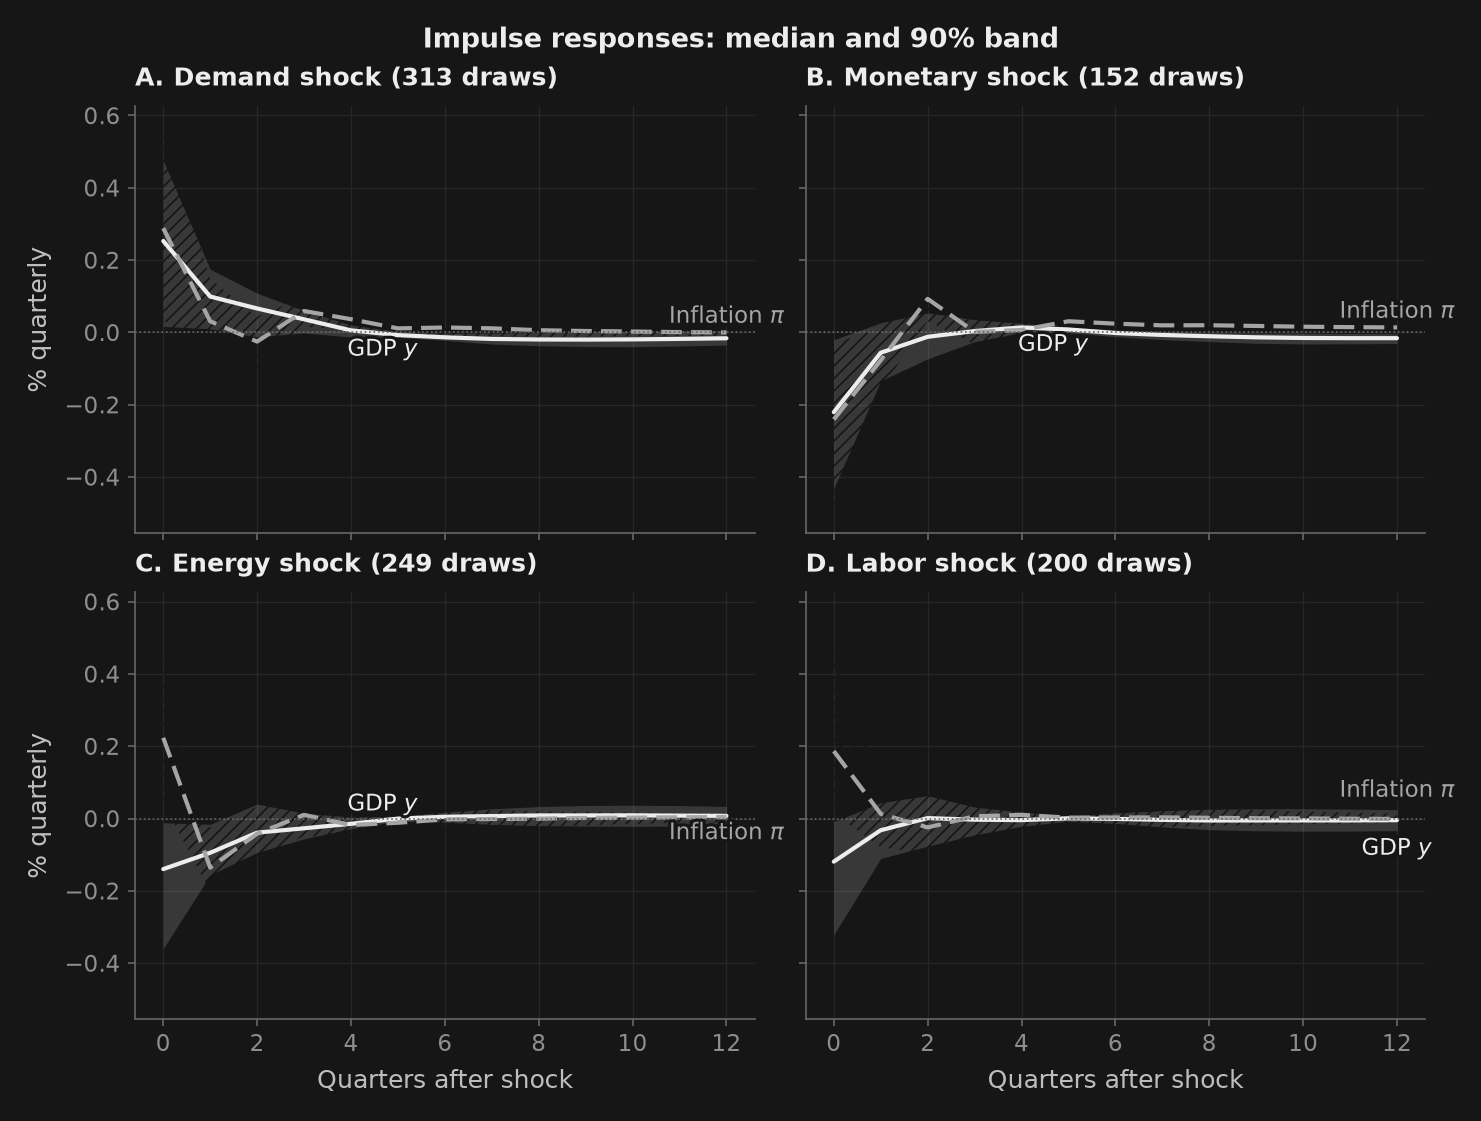

In [6]:
# Impulse response functions with 90% credible intervals across admissible rotations
fig, axes = _nbstyle.figura(2, 2, sharex=True, sharey=True)
h = np.arange(H + 1)

titles = {"Demand": "A. Demand shock", "Monetary": "B. Monetary shock",
          "Energy": "C. Energy shock", "Labor": "D. Labor shock"}

for ax, (name, fit) in zip(axes.flat, fits.items()):
    # Real output growth and CPI inflation responses
    ax.plot(h, fit.irf_median[:, 0, 0], **_nbstyle.S1, label=r"GDP $y$")
    ax.fill_between(h, fit.irf_lower[:, 0, 0], fit.irf_upper[:, 0, 0], color=_nbstyle.BANDA, lw=0)

    ax.plot(h, fit.irf_median[:, 1, 0], **_nbstyle.S2, label=r"Inflation $\pi$")
    ax.fill_between(h, fit.irf_lower[:, 1, 0], fit.irf_upper[:, 1, 0], facecolor="none", hatch="////", lw=0)

    ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(f"{titles[name]} ({fit.n_accepted} draws)")

for ax in axes[:, 0]:
    ax.set_ylabel("% quarterly")

for ax in axes[1]:
    ax.set_xlabel("Quarters after shock")

# the plain band belongs to GDP and the hatched one to inflation: both are 90% of the rotations
fig.suptitle("Impulse responses: median and 90% band")
for ax in axes.flat:
    _nbstyle.etiquetar(ax)
plt.show()


## 3. Empirical Experiment: Historical Shock Decomposition of Post-COVID Inflation

To quantify the exact percentage-point contribution of each structural disturbance across every quarter, we identify a joint orthogonal rotation matrix $Q \in \mathcal{O}(n)$ such that the structural impact matrix $B^* = P Q$ **simultaneously** satisfies the sign restrictions for all four structural shocks.

Given the structural impact matrix $B^*$, we invert the reduced-form residuals:
$$ \varepsilon_t = (B^*)^{-1} u_t, \qquad u_t = Y_t - c - A_1 Y_{t-1} - A_2 Y_{t-2} $$
and forward-simulate the dynamic contribution of each shock $j$ to inflation $\pi_t$:
$$ Y_t^{(j)} = A_1 Y_{t-1}^{(j)} + A_2 Y_{t-2}^{(j)} + B_{\cdot, j}^* \, \varepsilon_{j, t} $$
This isolates how much of the deviation of headline CPI inflation from the model's deterministic path $\pi_t^{\mathrm{det}}$ (the constant plus the propagation of the 2020Q3–Q4 initial conditions) was generated by Demand, Monetary Policy, Energy/Commodity Spikes, and Labor Market Tightness. The fifth column of $B^*$ carries no sign restrictions, so we report it as an unidentified shock; with it, the decomposition is exact: $\pi_t - \pi_t^{\mathrm{det}} = \sum_{j=1}^{5} \pi_t^{(j)}$.

In [7]:
# Joint structural identification and historical shock decomposition
res_var = estimate_var(Y_est, p=p)
P = safe_cholesky(res_var.Sigma)
n = 5

target_signs = [
    np.array([+1, +1,  0, +1, +1]),  # Demand
    np.array([-1, -1,  0, -1, +1]),  # Monetary
    np.array([-1, +1, +1, -1,  0]),  # Energy
    np.array([-1, +1,  0, +1,  0]),  # Labor
]

def check_col(b, signs):
    for i, s in enumerate(signs):
        if s != 0 and np.sign(b[i]) != s:
            return False
    return True

rng = np.random.default_rng(123)
joint_accepted = []
for draw in range(4000):
    R = _draw_orthogonal(n, rng)
    B = P @ R
    matches = {s_idx: [] for s_idx in range(4)}
    for col in range(n):
        for sign_mult in [+1, -1]:
            b_cand = sign_mult * B[:, col]
            for s_idx in range(4):
                if check_col(b_cand, target_signs[s_idx]):
                    matches[s_idx].append((col, sign_mult))
    found = False
    for c0, s0 in matches[0]:
        for c1, s1 in matches[1]:
            if c1 == c0: continue
            for c2, s2 in matches[2]:
                if c2 in (c0, c1): continue
                for c3, s3 in matches[3]:
                    if c3 in (c0, c1, c2): continue
                    B_perm = np.zeros_like(B)
                    B_perm[:, 0] = s0 * B[:, c0]
                    B_perm[:, 1] = s1 * B[:, c1]
                    B_perm[:, 2] = s2 * B[:, c2]
                    B_perm[:, 3] = s3 * B[:, c3]
                    rem = list(set(range(5)) - {c0, c1, c2, c3})[0]
                    B_perm[:, 4] = B[:, rem]
                    joint_accepted.append(B_perm)
                    found = True
                    break
                if found: break
            if found: break
        if found: break

assert len(joint_accepted) > 50, "Insufficient jointly accepted structural matrices"

# Select representative central matrix (closest to the pointwise median impact)
median_impact = np.median(joint_accepted, axis=0)
dist = [np.linalg.norm(B - median_impact) for B in joint_accepted]
best_B = joint_accepted[np.argmin(dist)]

# Dynamic historical decomposition over 2021Q1-2024Q4
inv_B = np.linalg.inv(best_B)
A1, A2 = res_var.A_list[0], res_var.A_list[1]
c_vec = res_var.c

full_Y = df_macro.values
dates = df_macro.index
post_mask = (dates >= "2021-01-01") & (dates <= "2024-12-31")
post_idx = np.where(post_mask)[0]

u_post = [full_Y[t] - c_vec - A1 @ full_Y[t-1] - A2 @ full_Y[t-2] for t in post_idx]
eps_post = np.array([inv_B @ u for u in u_post])

# "Other" is the fifth column of B*, which carries no sign restrictions (unidentified shock)
shock_names = ["Demand", "Monetary", "Energy", "Labor", "Other"]
decomp_pi = {}
for j, name in enumerate(shock_names):
    sim = np.zeros((len(post_idx) + 2, n))
    for t_idx in range(len(post_idx)):
        impact = best_B[:, j] * eps_post[t_idx, j]
        sim[t_idx + 2] = A1 @ sim[t_idx + 1] + A2 @ sim[t_idx] + impact
    decomp_pi[name] = sim[2:, 1]

df_decomp = pd.DataFrame(decomp_pi, index=dates[post_idx])
df_decomp["Actual_Inflation"] = df_macro.loc["2021":"2024", "pi"].values

# Deterministic path: the constant plus the propagation of the 2020Q3-Q4 initial conditions
det = np.zeros((len(post_idx) + 2, n))
det[:2] = full_Y[post_idx[0] - 2:post_idx[0]]
for t_idx in range(len(post_idx)):
    det[t_idx + 2] = c_vec + A1 @ det[t_idx + 1] + A2 @ det[t_idx]
df_decomp["Deterministic_Path"] = det[2:, 1]

# The decomposition is exact: the five contributions add up to pi_t minus its deterministic path
hd_gap = df_decomp["Actual_Inflation"] - df_decomp["Deterministic_Path"] - df_decomp[shock_names].sum(axis=1)
assert np.abs(hd_gap).max() < 1e-10, "Historical decomposition does not add up"

print("Historical shock decomposition of inflation (annual means in percentage-point contributions):")
print(df_decomp.groupby(df_decomp.index.year).mean()[shock_names].round(2))

Historical shock decomposition of inflation (annual means in percentage-point contributions):
                  Demand  Monetary  Energy  Labor  Other
observation_date                                        
2021                0.49      0.89   -0.00  -0.37   0.26
2022                1.69     -1.25    0.29  -0.11   0.61
2023                1.84     -0.72   -0.22  -0.32  -0.11
2024                1.36      0.18   -0.45  -0.24  -0.45


**Chronology Revealed by the Structural Decomposition.**

The quantitative decomposition demonstrates the precise timeline documented by Bernanke & Blanchard:

1. **Phase 1 (2021): Reopening under accommodative policy.** In 2021, the largest contribution to above-target inflation came from accommodative monetary policy ($+0.89$ pp average quarterly contribution), with the aggregate demand shock adding $+0.49$ pp and energy disruptions not yet a factor.
2. **Phase 2 (2022): The Stagflationary Energy Shock & Monetary Response.** Following the war in Ukraine and refining bottlenecks, commodity price shocks surged in 2022Q1 and 2022Q2, although aggregate demand remained the largest positive contributor over the year ($+1.69$ pp average quarterly contribution). In response, rapid Fed interest rate increases began exerting strong downward pressure in late 2022 and 2023 ($-1.25$ pp average quarterly contribution in 2022, $-0.72$ pp in 2023). The unidentified component ($+0.61$ pp) was larger than the energy contribution ($+0.29$ pp) that year, so the sign restrictions leave a sizable share of 2022 inflation unexplained.
3. **Phase 3 (2023–2024): Immaculate Disinflation.** Throughout 2023 and 2024, energy contributions swung strongly negative ($-0.22$ pp in 2023 and $-0.45$ pp in 2024), pulling inflation downward. Simultaneously, labor market tightness $\theta = v/u$ cooled toward $1.05$ without pushing up unemployment: an immaculate adjustment along the steep segment of the Beveridge curve.

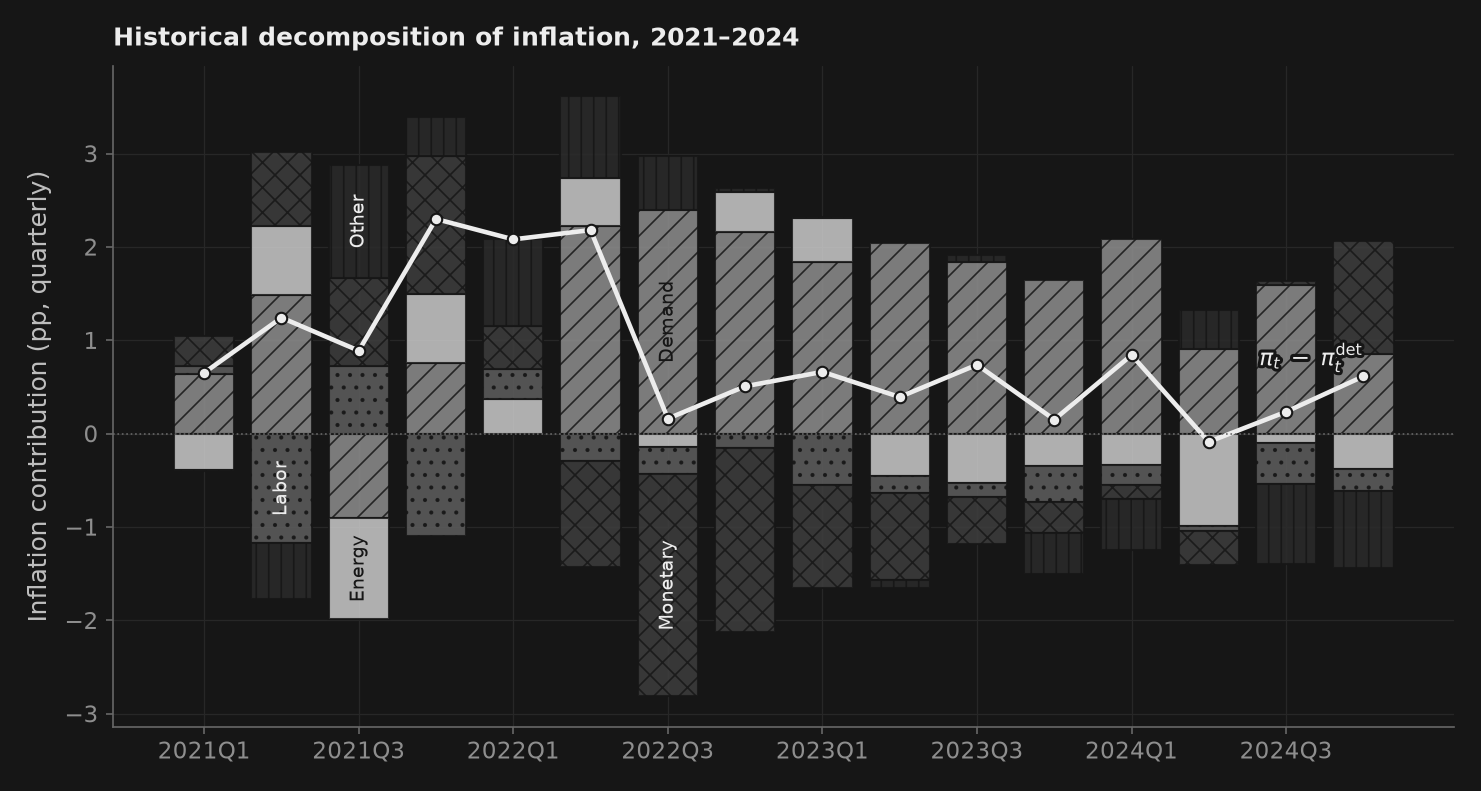

In [8]:
# Stacked bar visualization: shock contributions to quarterly inflation deviations
# "2_alto" is the wide, tall strip: stacked bars need height to carry each
# shock's name inside its own segment
fig, ax = _nbstyle.figura(figsize="2_alto")

x = np.arange(len(df_decomp))
quarters = df_decomp.index.to_period("Q").strftime("%YQ%q")

# Each shock stacks on the same-sign contributions of the shocks drawn before it;
# the unidentified shock gets a faint fill with its own hatch
pos_bottom = np.zeros(len(df_decomp))
neg_bottom = np.zeros(len(df_decomp))
for shock, fill, hatch, tinta in [
        ("Demand", _nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_HATCH[1], _nbstyle.FONDO),
        ("Energy", _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_HATCH[0], _nbstyle.FONDO),
        ("Labor", _nbstyle.BARRA_COLORES[2], _nbstyle.BARRA_HATCH[2], _nbstyle.TINTA),
        ("Monetary", _nbstyle.BARRA_COLORES[3], _nbstyle.BARRA_HATCH[3], _nbstyle.TINTA),
        ("Other", _nbstyle.tono(0.12), "||", _nbstyle.TINTA)]:
    vals = df_decomp[shock].to_numpy()
    base = np.where(vals >= 0, pos_bottom, neg_bottom)
    ax.bar(x, vals, width=0.78, bottom=base, color=fill, hatch=hatch,
           edgecolor=_nbstyle.FONDO, lw=1, alpha=0.85)
    # the name goes inside the shock's thickest segment, in the gray that contrasts with its fill
    k = int(np.argmax(np.abs(vals)))
    ax.text(x[k], base[k] + vals[k] / 2, shock, rotation=90, ha="center", va="center",
            color=tinta, fontsize=9)      # inside a bar: as tight as an axis tick label
    pos_bottom += np.clip(vals, 0, None)
    neg_bottom += np.clip(vals, None, 0)

ax.plot(x, df_decomp["Actual_Inflation"] - df_decomp["Deterministic_Path"],
        color=_nbstyle.TINTA, ls="-", lw=2.2, marker="o", mec=_nbstyle.FONDO,
        label=r"$\pi_t \;-\; \pi_t^{\mathrm{det}}$")

ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax.set_xticks(x[::2])
ax.set_xticklabels(quarters[::2])
ax.set_ylabel("Inflation contribution (pp, quarterly)")
ax.set_title("Historical decomposition of inflation, 2021–2024")
_nbstyle.etiquetar(ax, donde="fin", fuera=False)
plt.show()


## 4. Student Lab & Policy Counterfactual Experiment

**Macroeconomic Policy Question:**
*What trajectory would US inflation have followed had energy and commodity prices not experienced the massive geopolitical spike of 2022 following the invasion of Ukraine?*

**Student Instructions:**
1. In the cell below, simulate the counterfactual path where energy shock innovations are set to zero throughout 2022 ($\varepsilon_t^{\text{Energy}} = 0$ for $t \in [2022Q1, 2022Q4]$).
2. Compare the observed peak inflation against the counterfactual peak.
3. Assess whether inflation would have converged toward the $2\%$ annual ($0.5\%$ quarterly) objective significantly sooner.

In [9]:
# Policy Counterfactual: What would have happened without the 2022 energy price shock?
# Set the energy innovations to zero in 2022Q1-2022Q4 only and propagate the difference
j_energy = shock_names.index("Energy")
eps_energy_2022 = np.where(df_decomp.index.year == 2022, eps_post[:, j_energy], 0.0)
sim = np.zeros((len(post_idx) + 2, n))
for t_idx in range(len(post_idx)):
    sim[t_idx + 2] = A1 @ sim[t_idx + 1] + A2 @ sim[t_idx] + best_B[:, j_energy] * eps_energy_2022[t_idx]
df_decomp["Energy_2022"] = sim[2:, 1]
df_decomp["Inflation_No_Energy"] = df_decomp["Actual_Inflation"] - df_decomp["Energy_2022"]

observed_peak = df_decomp.loc["2022", "Actual_Inflation"].max()
counterfactual_peak = df_decomp.loc["2022", "Inflation_No_Energy"].max()
peak_date = df_decomp.loc["2022", "Actual_Inflation"].idxmax().to_period("Q")

print("POLICY COUNTERFACTUAL RESULTS (2022):")
print(f"- Observed quarterly peak inflation ({peak_date}): {observed_peak:.2f}% ({4 * observed_peak:.1f}% annualized)")
print(f"- Counterfactual peak inflation (no energy shock): {counterfactual_peak:.2f}% ({4 * counterfactual_peak:.1f}% annualized)")
print(f"- Peak inflation reduction from absent energy shock: {observed_peak - counterfactual_peak:.2f} pp")

# Automated macroeconomic consistency assertions
assert observed_peak > counterfactual_peak, "Counterfactual without energy shock must have a strictly lower peak"
assert (observed_peak - counterfactual_peak) > 0.3, "Energy shock must explain at least 0.3 pp of the 2022 peak"
assert df_decomp.loc["2023":"2024", "Energy"].mean() < 0.1, "Energy shock contributions must turn disinflationary in 2023-2024"
print("\n✓ All empirical and counterfactual consistency assertions passed successfully!")

POLICY COUNTERFACTUAL RESULTS (2022):
- Observed quarterly peak inflation (2022Q2): 2.50% (10.0% annualized)
- Counterfactual peak inflation (no energy shock): 2.09% (8.4% annualized)
- Peak inflation reduction from absent energy shock: 0.41 pp

✓ All empirical and counterfactual consistency assertions passed successfully!


## 5. Theoretical Synthesis & Econometric Frontiers

This empirical exercise illustrates both the analytical power and practical boundaries of structural identification:

1. **The single-cause fallacy.** The 2021–2024 inflation wave was neither solely a fiscal-monetary demand error nor purely an unavoidable external supply shock. It began as a demand and reopening surge in 2021, was compounded in 2022 by a severe commodity and supply chain shock amid unprecedented labor market tightness ($\theta = 1.93$)—although in the decomposition aggregate demand remained the largest contributor that year ($+1.69$ pp average quarterly contribution), with energy's contribution modest ($+0.29$ pp) and labor's slightly negative ($-0.11$ pp)—and receded in 2023–2024 as supply normalized and inflation expectations remained anchored.
2. **The anchoring of long-term expectations.** Why did the US avoid the persistent stagflation of the 1970s? Bernanke & Blanchard emphasize that 5-to-10 year inflation expectations remained anchored near $2\%$. Because expectations never became unmoored, transitory price level shocks did not permanently embed themselves into core nominal wage bargaining.
3. **Boundaries of sign identification.** Sign restrictions provide **set identification**: they delineate the range of admissible models without producing a unique point estimate. While the representative rotation chosen here illuminates central tendencies, rigorous econometric reporting requires calculating the full envelope of credible intervals across admissible rotations (Fry & Pagan 2011).